In [1]:
import sys
sys.path.append("/home/landelle/pytorch-cifar/models")
#import util
import resnet
import numpy as np
import torch
import torchvision

import mix_utils

In [2]:

transform = torchvision.transforms.transforms.Compose([
    torchvision.transforms.transforms.ToTensor()
])

base_trainset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=True, download=True, transform=transform)
base_testset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=False, download=True, transform=transform)

base_trainset, base_testset

Files already downloaded and verified
Files already downloaded and verified


(Dataset CIFAR10
     Number of datapoints: 50000
     Root location: /data/landelle/datasets
     Split: Train
     StandardTransform
 Transform: Compose(
                ToTensor()
            ), Dataset CIFAR10
     Number of datapoints: 10000
     Root location: /data/landelle/datasets
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
            ))

In [21]:

BATCH_SIZE = 100
N_BATCHES_IN_TRAIN_SET = len(base_trainset) // BATCH_SIZE
N_BATCHES_IN_TEST_SET = len(base_testset) // BATCH_SIZE

NUM_WORKERS = 8

# Fixed learning rate
# Lowered learning rate from 0.05
LR = 0.005 #0.005 LR=0.1 is used by kuangliu with his implementation of ResNet18 for epochs [0;150)

# CIFAR10 number of classes
NUM_CLASS = 10

# CIFAR10 image metadata
CHANNEL, IMAGE_SIZE, _ = base_trainset[0][0].shape
print("images are:", IMAGE_SIZE, CHANNEL)


images are: 32 3


In [4]:

trainloader = torch.utils.data.DataLoader(base_trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
testloader = torch.utils.data.DataLoader(base_testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


In [22]:
def pmix_masks(n, im_dim, single):
    """ Makes pmix masks
    Args:
        n: int, the number of masks to make (one for each unique label)
        im_dim: tuple, width and height of images and thus masks
        single: bool, when activated this function will return the same mask for each label
    Return:
        np.array of shape [n, im_dim[0], im_dim[1]], the list of masks for respective labels
    """
    masks = np.zeros((n, *im_dim), dtype=int)
    for i in range(masks.shape[0]):
        if single and i > 0:
            masks[i] = masks[0]
            continue
        rrange = np.arange(0, im_dim[0]*im_dim[1])
        np.random.shuffle(rrange)
        masks[i] = rrange.reshape(im_dim)
    return masks

def pmix_images(imgs, labels, masks, device):
    H, W = masks[0].shape
    
    # Makes empty result array
    pmixed = torch.empty(imgs.shape).to(device)
    for i in range(imgs.shape[0]):
        # Flatten mask for this label
        rs_mask = masks[labels[i]].reshape(W * H)
        # Flatten image
        rs_img = imgs[i].reshape((-1, W * H))
        # Mix pixels of img according to mask, accross each channel
        rs_result = rs_img[:, rs_mask]
    
        pmixed[i] = rs_result.reshape((-1, W, H))
    return pmixed


In [45]:

from nmixup import resnet18, get_print, mixup_data_nmix, mixup_criterion_nmix

USE_CUDA = True
N_EPOCHS = 100
N_BATCHES = None
LAMBDA_VEC = np.array((.75, .25))
NMIX = LAMBDA_VEC.shape[0]

model_getter = resnet18

MASKS = pmix_masks(10, (32, 32), True)
        
print_ = get_print(True, fname="results_mixup_pmix_LRadapt_"+str(i))

device = torch.device('cuda' if USE_CUDA else 'cpu')
model = model_getter().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = torch.nn.CrossEntropyLoss()

lam_rs = LAMBDA_VEC.reshape((-1, 1, 1, 1, 1))
lam_rs_tensor = torch.from_numpy(lam_rs).float().to(device)

# switch to train mode
model.train()
for epoch in range(1, N_EPOCHS + 1):
    print_("Epoch[{}/{}]".format(epoch, N_EPOCHS))
    for batch_id, (images, labels) in enumerate(trainloader):
        if N_BATCHES and batch_id > N_BATCHES:
            break
        labels, images = labels.to(device), images.to(device).float()
        #mix_utils.show_np_array(images_shuffled.cpu()[0])
        images_mixup, ys, perms = mixup_data_nmix(NMIX, images, labels, lam_rs_tensor)
        images_shuffled = pmix_images(images_mixup, ys[0], MASKS, device)
        #outputs = model(images.float())
        outputs = model(images_shuffled)
        loss = mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_id % 50 == 0:
            print_('Loss :{:.4f} Epoch[{}/{}] Batch[{}/{}] batch_shape:{}'.format(
                loss.item(), epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET, images.shape))

test_accs = {}



Epoch[1/100]
Loss :2.3968 Epoch[1/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.2428 Epoch[1/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.1422 Epoch[1/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.1678 Epoch[1/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.0504 Epoch[1/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.0311 Epoch[1/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.9667 Epoch[1/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.0238 Epoch[1/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.9205 Epoch[1/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.0081 Epoch[1/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[2/100]
Loss :2.0254 Epoch[2/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.8818 Epoch[2/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 3

Loss :1.6483 Epoch[10/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[11/100]
Loss :1.5035 Epoch[11/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.4956 Epoch[11/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.5498 Epoch[11/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.4315 Epoch[11/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.4701 Epoch[11/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.5048 Epoch[11/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.3988 Epoch[11/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.5509 Epoch[11/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.5686 Epoch[11/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.5323 Epoch[11/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[12/100]
Loss :1.4888 Epoch[12/100] Batch[0/500] batch_shape:torch.Size

Loss :1.1952 Epoch[20/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2441 Epoch[20/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2733 Epoch[20/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[21/100]
Loss :1.0973 Epoch[21/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1334 Epoch[21/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1594 Epoch[21/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1953 Epoch[21/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1928 Epoch[21/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.3208 Epoch[21/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2987 Epoch[21/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2177 Epoch[21/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2413 Epoch[21/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32

Loss :1.0903 Epoch[30/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1711 Epoch[30/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1565 Epoch[30/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1173 Epoch[30/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1382 Epoch[30/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[31/100]
Loss :1.1058 Epoch[31/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1635 Epoch[31/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1518 Epoch[31/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0813 Epoch[31/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1261 Epoch[31/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1062 Epoch[31/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1075 Epoch[31/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32

Loss :1.1027 Epoch[40/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1154 Epoch[40/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0397 Epoch[40/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0866 Epoch[40/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0388 Epoch[40/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1072 Epoch[40/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0944 Epoch[40/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[41/100]
Loss :1.0422 Epoch[41/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0386 Epoch[41/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0666 Epoch[41/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0898 Epoch[41/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0525 Epoch[41/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32

...

Loss :0.9782 Epoch[59/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[60/100]
Loss :1.0476 Epoch[60/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0638 Epoch[60/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0050 Epoch[60/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0233 Epoch[60/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1316 Epoch[60/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1563 Epoch[60/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0558 Epoch[60/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1179 Epoch[60/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0817 Epoch[60/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0333 Epoch[60/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[61/100]
Loss :1.0815 Epoch[61/100] Batch[0/500] batch_shape:torch.Size

Loss :0.9830 Epoch[69/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0626 Epoch[69/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0447 Epoch[69/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[70/100]
Loss :1.0742 Epoch[70/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0889 Epoch[70/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0719 Epoch[70/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0265 Epoch[70/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0195 Epoch[70/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0253 Epoch[70/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0302 Epoch[70/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0429 Epoch[70/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0543 Epoch[70/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32

Loss :1.0378 Epoch[79/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0431 Epoch[79/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9649 Epoch[79/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0002 Epoch[79/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0188 Epoch[79/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[80/100]
Loss :1.0682 Epoch[80/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0305 Epoch[80/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0076 Epoch[80/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9955 Epoch[80/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0514 Epoch[80/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0210 Epoch[80/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0499 Epoch[80/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32

Loss :0.9709 Epoch[89/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0153 Epoch[89/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9506 Epoch[89/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0265 Epoch[89/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0173 Epoch[89/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9957 Epoch[89/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0629 Epoch[89/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[90/100]
Loss :0.9982 Epoch[90/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0039 Epoch[90/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9564 Epoch[90/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9973 Epoch[90/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0535 Epoch[90/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32

Loss :0.9824 Epoch[99/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0167 Epoch[99/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9967 Epoch[99/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0226 Epoch[99/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9864 Epoch[99/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0633 Epoch[99/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0083 Epoch[99/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0078 Epoch[99/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0929 Epoch[99/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[100/100]
Loss :1.0455 Epoch[100/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0264 Epoch[100/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0341 Epoch[100/100] Batch[100/500] batch_shape:torch.Size([100, 3,

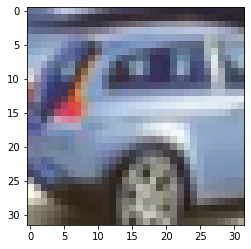

In [46]:
mix_utils.show_np_array(images[perms[0][0]].cpu())

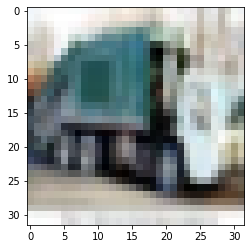

In [47]:
mix_utils.show_np_array(images[perms[1][0]].cpu())

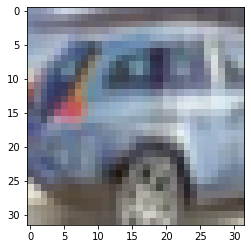

In [48]:
mix_utils.show_np_array(images_mixup[0].cpu())

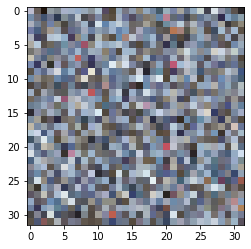

In [49]:
mix_utils.show_np_array(images_shuffled[0].cpu())

In [50]:

# switch to evaluate mode
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images_ts, labels in testloader:
        images_ts = images_ts.to(device).float()
        labels = labels.to(device)
        images_ts_shuffled = pmix_images(images_ts, labels, MASKS, device)
        outputs = model(images_ts_shuffled)
        predicted = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    # Output test accuracy
    test_acc = 100 * correct / total
    print_('Test Accuracy of the model on the test images: {} %'.format(test_acc))

    test_acc = test_acc
    

Test Accuracy of the model on the test images: 56.68 %


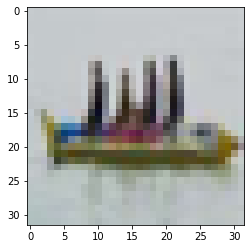

In [55]:
mix_utils.show_np_array(images_ts.cpu()[0])

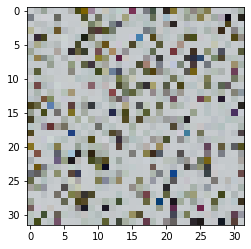

In [54]:
mix_utils.show_np_array(images_ts_shuffled.cpu()[0])

In [12]:
del device, model, optimizer, criterion